# Driblab Capstone Project EDA

## Data from the UEFA Champions League 2023/2024 

### EDA for the shot_pack/shots directory which contains all the data from each match in JSON format

In [877]:
import glob
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [878]:
pd.set_option('display.max_rows', None)      # show every row
pd.set_option('display.max_columns', None)   # (optional) show every column

## Reading all JSON files from shots

In [ ]:
files = glob.glob('../shot_pack/shots/*.json')          
dfs   = []
for fp in files:
    with open(fp) as f:
        dfs.append(pd.json_normalize(json.load(f), sep='_'))

shots = pd.concat(dfs, ignore_index=True)
shots.head()

/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_7907/1424478464.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shots = pd.concat(dfs, ignore_index=True)


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,relatedEventId,pass,groundDuel,aerialDuel,infraction,carry,type_primary,type_secondary,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,player_position,shot_bodyPart,shot_isGoal,shot_onTarget,shot_goalZone,shot_xg,shot_postShotXg,shot_goalkeeperActionId,shot_goalkeeper_id,shot_goalkeeper_name,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_withShot,possession_attack_withShotOnGoal,possession_attack_withGoal,possession_attack_flank,possession_attack_xg,shot_goalkeeper
0,2456216417,5589317,1H,1,45,00:01:45.710,106.710013,None,None,None,None,None,None,shot,"[opportunity, touch_in_box]",91,33,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,596052,Ander Barrenetxea,LWF,left_foot,False,True,glb,0.10740,0.1153,2.456217e+09,56038.0,J. Lössl,0.109,2456216411,16.4749855,[attack],9,8,5,10,91,33,687,Real Sociedad,4-3-3,True,True,False,center,0.1074,NaN
1,2456216425,5589317,1H,4,3,00:04:03.051,244.051591,None,None,None,None,None,None,shot,"[goal, opportunity, touch_in_box]",92,57,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,302550,Brais Méndez,RCMF3,left_foot,True,True,gb,0.34900,0.3991,2.456217e+09,56038.0,J. Lössl,0.287,2456216425,0.0,[attack],1,0,92,57,92,57,687,Real Sociedad,4-3-3,True,True,True,center,0.3490,NaN
2,2456216439,5589317,1H,5,57,00:05:57.191,358.191312,None,None,None,None,None,None,shot,[],78,61,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,504301,T. Kubo,RWF,left_foot,False,False,bc,0.02149,NaN,NaN,NaN,NaN,0.040,2456216435,7.559862,"[counterattack, attack]",8,7,34,53,78,61,687,Real Sociedad,4-3-3,True,False,False,center,0.0215,NaN
3,2456216441,5589317,1H,6,40,00:06:40.217,401.217472,None,None,None,None,None,None,shot,"[head_shot, opportunity, shot_after_corner, to...",95,49,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,278288,Aritz Elustondo,RB,head_or_other,False,False,otr,0.21790,NaN,NaN,NaN,NaN,0.209,2456216440,0.9268215,"[corner, set_piece_attack, attack]",2,1,100,100,95,49,687,Real Sociedad,4-3-3,True,False,False,right,0.2179,NaN
4,2456216465,5589317,1H,9,36,00:09:36.857,577.857487,None,None,None,None,None,None,shot,[touch_in_box],90,61,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,355599,Mikel Oyarzabal,CF,left_foot,False,False,bc,0.04259,NaN,NaN,NaN,NaN,0.172,2456216453,23.9951145,"[set_piece_attack, attack, free_kick]",18,17,29,72,90,61,687,Real Sociedad,4-3-3,True,False,False,left,0.0426,NaN


In [880]:
shots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4582 entries, 0 to 4581
Data columns (total 54 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                4582 non-null   int64  
 1   matchId                           4582 non-null   int64  
 2   matchPeriod                       4582 non-null   object 
 3   minute                            4582 non-null   int64  
 4   second                            4582 non-null   int64  
 5   matchTimestamp                    4582 non-null   object 
 6   videoTimestamp                    4582 non-null   object 
 7   relatedEventId                    0 non-null      object 
 8   pass                              0 non-null      object 
 9   groundDuel                        0 non-null      object 
 10  aerialDuel                        0 non-null      object 
 11  infraction                        0 non-null      object 
 12  carry 

## Checking for columns with null values and dropping the ones with 100% null values

In [881]:
na_counts = shots.isna().sum().sort_values(ascending=False)


na_pct = (na_counts / len(shots) * 100).round(2)
na_report = pd.concat([na_counts, na_pct], axis=1, keys=['n_missing', 'pct'])
print("\nNA REPORT:")
print(na_report[na_report['n_missing'] > 0].head(20))  # top 20 missing cols



NA REPORT:
                         n_missing     pct
shot_goalkeeper               4582  100.00
aerialDuel                    4582  100.00
carry                         4582  100.00
infraction                    4582  100.00
relatedEventId                4582  100.00
pass                          4582  100.00
groundDuel                    4582  100.00
shot_goalkeeperActionId       2836   61.89
shot_goalkeeper_id            2836   61.89
shot_goalkeeper_name          2836   61.89
shot_postShotXg               2836   61.89


In [882]:
shots = shots.drop(columns=["aerialDuel", "pass", "carry", "infraction", "groundDuel", "shot_goalkeeper", "relatedEventId"])

In [883]:
shots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4582 entries, 0 to 4581
Data columns (total 47 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                4582 non-null   int64  
 1   matchId                           4582 non-null   int64  
 2   matchPeriod                       4582 non-null   object 
 3   minute                            4582 non-null   int64  
 4   second                            4582 non-null   int64  
 5   matchTimestamp                    4582 non-null   object 
 6   videoTimestamp                    4582 non-null   object 
 7   type_primary                      4582 non-null   object 
 8   type_secondary                    4582 non-null   object 
 9   location_x                        4582 non-null   int64  
 10  location_y                        4582 non-null   int64  
 11  team_id                           4582 non-null   int64  
 12  team_n

## Looking into columns with a unique value and dropping them

In [884]:
print(shots['type_primary'].unique())  # check unique values in 'type_primary' column
print(shots['possession_attack_withShot'].unique())  # check unique values in 'type_primary' column

['shot']
[ True]


In [885]:
shots = shots.drop(columns=["type_primary", "possession_attack_withShot"])

## Analyzing which categorical columns make sense to be one hot encoded

In [886]:
print(shots['possession_attack_flank'].unique())  # check unique values in 'type_primary' column
print(shots['shot_bodyPart'].unique())  # check unique values in 'type_primary' column

['center' 'right' 'left']
['left_foot' 'head_or_other' 'right_foot']


In [887]:
shots = pd.get_dummies(shots, columns=['possession_attack_flank'], prefix='flank')
shots = pd.get_dummies(shots, columns=['shot_bodyPart'])


In [888]:
shots.head()


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,type_secondary,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,player_position,shot_isGoal,shot_onTarget,shot_goalZone,shot_xg,shot_postShotXg,shot_goalkeeperActionId,shot_goalkeeper_id,shot_goalkeeper_name,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_withShotOnGoal,possession_attack_withGoal,possession_attack_xg,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot
0,2456216417,5589317,1H,1,45,00:01:45.710,106.710013,"[opportunity, touch_in_box]",91,33,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,596052,Ander Barrenetxea,LWF,False,True,glb,0.10740,0.1153,2.456217e+09,56038.0,J. Lössl,0.109,2456216411,16.4749855,[attack],9,8,5,10,91,33,687,Real Sociedad,4-3-3,True,False,0.1074,True,False,False,False,True,False
1,2456216425,5589317,1H,4,3,00:04:03.051,244.051591,"[goal, opportunity, touch_in_box]",92,57,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,302550,Brais Méndez,RCMF3,True,True,gb,0.34900,0.3991,2.456217e+09,56038.0,J. Lössl,0.287,2456216425,0.0,[attack],1,0,92,57,92,57,687,Real Sociedad,4-3-3,True,True,0.3490,True,False,False,False,True,False
2,2456216439,5589317,1H,5,57,00:05:57.191,358.191312,[],78,61,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,504301,T. Kubo,RWF,False,False,bc,0.02149,NaN,NaN,NaN,NaN,0.040,2456216435,7.559862,"[counterattack, attack]",8,7,34,53,78,61,687,Real Sociedad,4-3-3,False,False,0.0215,True,False,False,False,True,False
3,2456216441,5589317,1H,6,40,00:06:40.217,401.217472,"[head_shot, opportunity, shot_after_corner, to...",95,49,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,278288,Aritz Elustondo,RB,False,False,otr,0.21790,NaN,NaN,NaN,NaN,0.209,2456216440,0.9268215,"[corner, set_piece_attack, attack]",2,1,100,100,95,49,687,Real Sociedad,4-3-3,False,False,0.2179,False,False,True,True,False,False
4,2456216465,5589317,1H,9,36,00:09:36.857,577.857487,[touch_in_box],90,61,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,355599,Mikel Oyarzabal,CF,False,False,bc,0.04259,NaN,NaN,NaN,NaN,0.172,2456216453,23.9951145,"[set_piece_attack, attack, free_kick]",18,17,29,72,90,61,687,Real Sociedad,4-3-3,False,False,0.0426,False,True,False,False,True,False


In [889]:
shots['player_position'].unique()  # check unique values in 'type_primary' column

array(['LWF', 'RCMF3', 'RWF', 'RB', 'CF', 'LCMF3', 'LB', 'LW', 'LCMF',
       'RW', 'DMF', 'RCB', 'RAMF', 'RCMF', 'RDMF', 'LDMF', 'AMF', 'LCB',
       'LAMF', 'SS', 'RWB', 'RB5', 'CB', 'LWB', 'LCB3', 'RCB3', 'LB5'],
      dtype=object)

In [890]:
# Define mapping
position_map = {
    # Attackers
    'CF': 'attacker', 'SS': 'attacker', 'LW': 'attacker', 'RW': 'attacker',
    'LWF': 'attacker', 'RWF': 'attacker',

    # Midfielders
    'AMF': 'midfielder', 'RAMF': 'midfielder', 'LAMF': 'midfielder',
    'DMF': 'midfielder', 'LDMF': 'midfielder', 'RDMF': 'midfielder',
    'LCMF': 'midfielder', 'RCMF': 'midfielder', 'LCMF3': 'midfielder', 'RCMF3': 'midfielder',

    # Defenders
    'CB': 'defender', 'RB': 'defender', 'LB': 'defender', 'LCB': 'defender', 'RCB': 'defender',
    'LCB3': 'defender', 'RCB3': 'defender', 'LB5': 'defender', 'RB5': 'defender',
    'LWB': 'defender', 'RWB': 'defender'
}

# Apply to the DataFrame
shots['player_position'] = shots['player_position'].map(position_map)


In [891]:
shots = pd.get_dummies(shots, columns=['player_position'])

In [892]:
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,type_secondary,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,shot_isGoal,shot_onTarget,shot_goalZone,shot_xg,shot_postShotXg,shot_goalkeeperActionId,shot_goalkeeper_id,shot_goalkeeper_name,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_withShotOnGoal,possession_attack_withGoal,possession_attack_xg,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder
0,2456216417,5589317,1H,1,45,00:01:45.710,106.710013,"[opportunity, touch_in_box]",91,33,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,596052,Ander Barrenetxea,False,True,glb,0.10740,0.1153,2.456217e+09,56038.0,J. Lössl,0.109,2456216411,16.4749855,[attack],9,8,5,10,91,33,687,Real Sociedad,4-3-3,True,False,0.1074,True,False,False,False,True,False,True,False,False
1,2456216425,5589317,1H,4,3,00:04:03.051,244.051591,"[goal, opportunity, touch_in_box]",92,57,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,302550,Brais Méndez,True,True,gb,0.34900,0.3991,2.456217e+09,56038.0,J. Lössl,0.287,2456216425,0.0,[attack],1,0,92,57,92,57,687,Real Sociedad,4-3-3,True,True,0.3490,True,False,False,False,True,False,False,False,True
2,2456216439,5589317,1H,5,57,00:05:57.191,358.191312,[],78,61,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,504301,T. Kubo,False,False,bc,0.02149,NaN,NaN,NaN,NaN,0.040,2456216435,7.559862,"[counterattack, attack]",8,7,34,53,78,61,687,Real Sociedad,4-3-3,False,False,0.0215,True,False,False,False,True,False,True,False,False
3,2456216441,5589317,1H,6,40,00:06:40.217,401.217472,"[head_shot, opportunity, shot_after_corner, to...",95,49,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,278288,Aritz Elustondo,False,False,otr,0.21790,NaN,NaN,NaN,NaN,0.209,2456216440,0.9268215,"[corner, set_piece_attack, attack]",2,1,100,100,95,49,687,Real Sociedad,4-3-3,False,False,0.2179,False,False,True,True,False,False,False,True,False
4,2456216465,5589317,1H,9,36,00:09:36.857,577.857487,[touch_in_box],90,61,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,355599,Mikel Oyarzabal,False,False,bc,0.04259,NaN,NaN,NaN,NaN,0.172,2456216453,23.9951145,"[set_piece_attack, attack, free_kick]",18,17,29,72,90,61,687,Real Sociedad,4-3-3,False,False,0.0426,False,True,False,False,True,False,True,False,False


# Events After shot is taken shouldn't be taken into account so we will drop those columns



In [893]:
shots = shots.drop(columns=["type_secondary", "shot_goalkeeperActionId", "shot_postShotXg", "shot_goalZone", "shot_onTarget", "possession_attack_withGoal", "possession_attack_withShotOnGoal"])

In [894]:
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,shot_isGoal,shot_xg,shot_goalkeeper_id,shot_goalkeeper_name,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_xg,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder
0,2456216417,5589317,1H,1,45,00:01:45.710,106.710013,91,33,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,596052,Ander Barrenetxea,False,0.10740,56038.0,J. Lössl,0.109,2456216411,16.4749855,[attack],9,8,5,10,91,33,687,Real Sociedad,4-3-3,0.1074,True,False,False,False,True,False,True,False,False
1,2456216425,5589317,1H,4,3,00:04:03.051,244.051591,92,57,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,302550,Brais Méndez,True,0.34900,56038.0,J. Lössl,0.287,2456216425,0.0,[attack],1,0,92,57,92,57,687,Real Sociedad,4-3-3,0.3490,True,False,False,False,True,False,False,False,True
2,2456216439,5589317,1H,5,57,00:05:57.191,358.191312,78,61,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,504301,T. Kubo,False,0.02149,NaN,NaN,0.040,2456216435,7.559862,"[counterattack, attack]",8,7,34,53,78,61,687,Real Sociedad,4-3-3,0.0215,True,False,False,False,True,False,True,False,False
3,2456216441,5589317,1H,6,40,00:06:40.217,401.217472,95,49,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,278288,Aritz Elustondo,False,0.21790,NaN,NaN,0.209,2456216440,0.9268215,"[corner, set_piece_attack, attack]",2,1,100,100,95,49,687,Real Sociedad,4-3-3,0.2179,False,False,True,True,False,False,False,True,False
4,2456216465,5589317,1H,9,36,00:09:36.857,577.857487,90,61,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,355599,Mikel Oyarzabal,False,0.04259,NaN,NaN,0.172,2456216453,23.9951145,"[set_piece_attack, attack, free_kick]",18,17,29,72,90,61,687,Real Sociedad,4-3-3,0.0426,False,True,False,False,True,False,True,False,False


## Dropping repeated columns

In [895]:
print((shots['team_formation'] == shots['possession_team_formation']).all())
print((shots['team_id'] == shots['possession_team_id']).all())
print((shots['team_name'] == shots['possession_team_name']).all())
print((shots['location_x'] == shots['possession_endLocation_x']).all())
print((shots['location_y'] == shots['possession_endLocation_y']).all())
print((shots['shot_xg'] == shots['possession_attack_xg']).all())


True
True
True
True
True
False


In [896]:
mask = ~np.isclose(shots['shot_xg'], shots['possession_attack_xg'], atol=1e-4)
shots[mask]


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,shot_isGoal,shot_xg,shot_goalkeeper_id,shot_goalkeeper_name,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_xg,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder
124,2364807579,5588968,1H,28,54,00:28:54.661,1735.661917,79,59,11,PSV,4-3-3,756,Girona,4-4-2,289122,R. Karsdorp,False,0.13170,NaN,NaN,0.045,2364808556,2.322397,"[set_piece_attack, attack, free_kick, direct_f...",4,3,76,29,79,59,11,PSV,4-3-3,0.2091,True,False,False,False,False,True,False,True,False
185,2454492867,5589071,2H,78,11,01:18:11.373,4699.373663,78,56,2444,Bayern München,4-4-2,8508,Celtic,4-4-2,224593,J. Kimmich,False,0.12210,8480.0,K. Schmeichel,0.044,2454492866,1.252502,"[set_piece_attack, attack, free_kick, direct_f...",3,2,77,58,78,56,2444,Bayern München,4-4-2,0.2587,True,False,False,False,True,False,False,False,True
579,2513834799,5589340,1H,13,39,00:13:39.821,820.821957,86,68,678,Athletic Bilbao,4-2-3-1,8509,Rangers,4-4-1,247141,Iñaki Williams,False,0.07164,NaN,NaN,0.052,2513834795,5.1066065,"[set_piece_attack, attack, free_kick, direct_f...",6,5,82,67,86,68,678,Athletic Bilbao,4-2-3-1,0.1849,True,False,False,False,True,False,False,False,True
863,2455429394,5589069,2H,91,10,01:31:10.264,5619.264066,94,46,1625,Manchester City,4-3-1-2,675,Real Madrid,4-4-2,584520,Nico González,True,0.75540,3429.0,T. Courtois,0.256,2455429393,1.6725885,"[set_piece_attack, attack, free_kick, direct_f...",3,2,76,46,94,46,1625,Manchester City,4-3-1-2,0.8807,True,False,False,False,True,False,False,False,True
1456,2447652112,5589061,2H,59,42,00:59:42.670,3836.670689,91,45,675,Real Madrid,4-4-2,1625,Manchester City,4-1-4-1,353833,K. Mbappé,True,0.26890,71654.0,Ederson,0.318,2447652105,3.7398725,"[set_piece_attack, attack, free_kick, direct_f...",4,3,76,54,91,45,675,Real Madrid,4-4-2,0.3146,True,False,False,False,False,True,True,False,False
2069,2517669696,5589344,2H,57,43,00:57:43.263,3756.263633,93,50,8509,Rangers,4-4-2,678,Athletic Bilbao,4-2-3-1,513804,N. Raskin,False,0.36780,593446.0,Julen Agirrezabala,0.351,2517669674,11.7534245,"[set_piece_attack, attack, free_kick, direct_f...",9,8,78,65,93,50,8509,Rangers,4-4-2,0.4310,True,False,False,False,True,False,False,False,True
2505,2395250958,5589013,1H,16,2,00:16:02.238,963.238142,86,35,679,Atlético Madrid,4-4-2,14376,Slovan Bratislava,3-4-2-1,550459,J. Álvarez,True,0.15460,450507.0,D. Takáč,0.075,2395250912,63.4349935,"[set_piece_attack, attack, free_kick, direct_f...",25,24,76,49,86,35,679,Atlético Madrid,4-4-2,0.2652,False,True,False,False,False,True,True,False,False
3056,2381640945,5588994,1H,14,22,00:14:22.081,863.081184,86,53,3172,Atalanta,3-4-2-1,6408,Young Boys,4-3-3,516161,C. De Ketelaere,False,0.24220,268573.0,D. von Ballmoos,0.065,2381640944,0.902165,"[set_piece_attack, attack, free_kick, direct_f...",3,2,81,49,86,53,3172,Atalanta,3-4-2-1,0.4791,True,False,False,False,True,False,False,False,True
3149,2428634086,5589031,2H,65,7,01:05:07.743,4049.743915,86,73,9608,Sporting CP,4-4-2,2975,RB Leipzig,4-4-2,786686,Iván Fresneda,False,0.03018,NaN,NaN,0.043,2428634084,2.067177,"[set_piece_attack, attack, free_kick, direct_f...",5,4,75,62,86,73,9608,Sporting CP,4-4-2,0.1254,True,False,False,False,False,True,False,True,False
3541,2394240285,5589019,2H,81,30,01:21:30.392,5145.392621,85,50,3157,Milan,4-1-4-1,17090,Crvena Zvezda,4-4-1-1,520698,T. Reijnders,False,0.29120,NaN,NaN,0.062,2394240284,1.486954,"[set_piece_attack, attack, free_kick, direct_f...",3

In [897]:
mismatch_df = shots[mask].assign(
    diff = (shots['shot_xg'] - shots['possession_attack_xg']).abs()
).sort_values('diff', ascending=False)
mismatch_df.head(110)


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,shot_isGoal,shot_xg,shot_goalkeeper_id,shot_goalkeeper_name,shot_xg2,possession_id,possession_duration,possession_types,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,possession_endLocation_x,possession_endLocation_y,possession_team_id,possession_team_name,possession_team_formation,possession_attack_xg,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder,diff
3541,2394240285,5589019,2H,81,30,01:21:30.392,5145.392621,85,50,3157,Milan,4-1-4-1,17090,Crvena Zvezda,4-4-1-1,520698,T. Reijnders,False,0.29120,NaN,NaN,0.062,2394240284,1.486954,"[set_piece_attack, attack, free_kick, direct_f...",3,2,81,52,85,50,3157,Milan,4-1-4-1,0.5945,True,False,False,False,False,True,False,False,True,0.30330
4009,2493295935,5589330,2H,59,44,00:59:44.368,3721.368095,90,61,3162,Lazio,4-2-3-1,11255,Viktoria Plzeň,5-3-2,428012,M. Guendouzi,False,0.08030,NaN,NaN,0.070,2493295934,1.138803,"[set_piece_attack, attack, free_kick, direct_f...",3,2,80,53,90,61,3162,Lazio,4-2-3-1,0.3501,True,False,False,False,False,True,False,False,True,0.26980
3056,2381640945,5588994,1H,14,22,00:14:22.081,863.081184,86,53,3172,Atalanta,3-4-2-1,6408,Young Boys,4-3-3,516161,C. De Ketelaere,False,0.24220,268573.0,D. von Ballmoos,0.065,2381640944,0.902165,"[set_piece_attack, attack, free_kick, direct_f...",3,2,81,49,86,53,3172,Atalanta,3-4-2-1,0.4791,True,False,False,False,True,False,False,False,True,0.23690
3721,2440047938,5589045,1H,41,52,00:41:52.563,2513.563841,79,39,9417,Dinamo Zagreb,4-4-1-1,3157,Milan,4-4-1,217772,J. Mišić,False,0.07211,NaN,NaN,0.044,2440047936,1.8054015,"[set_piece_attack, attack, free_kick, direct_f...",4,3,81,29,79,39,9417,Dinamo Zagreb,4-4-1-1,0.2205,False,True,False,False,True,False,False,False,True,0.14839
185,2454492867,5589071,2H,78,11,01:18:11.373,4699.373663,78,56,2444,Bayern München,4-4-2,8508,Celtic,4-4-2,224593,J. Kimmich,False,0.12210,8480.0,K. Schmeichel,0.044,2454492866,1.252502,"[set_piece_attack, attack, free_kick, direct_f...",3,2,77,58,78,56,2444,Bayern München,4-4-2,0.2587,True,False,False,False,True,False,False,False,True,0.13660
863,2455429394,5589069,2H,91,10,01:31:10.264,5619.264066,94,46,1625,Manchester City,4-3-1-2,675,Real Madrid,4-4-2,584520,Nico González,True,0.75540,3429.0,T. Courtois,0.256,2455429393,1.6725885,"[set_piece_attack, attack, free_kick, direct_f...",3,2,76,46,94,46,1625,Manchester City,4-3-1-2,0.8807,True,False,False,False,True,False,False,False,True,0.12530
579,2513834799,5589340,1H,13,39,00:13:39.821,820.821957,86,68,678,Athletic Bilbao,4-2-3-1,8509,Rangers,4-4-1,247141,Iñaki Williams,False,0.07164,NaN,NaN,0.052,2513834795,5.1066065,"[set_piece_attack, attack, free_kick, direct_f...",6,5,82,67,86,68,678,Athletic Bilbao,4-2-3-1,0.1849,True,False,False,False,True,False,False,False,True,0.11326
2505,2395250958,5589013,1H,16,2,00:16:02.238,963.238142,86,35,679,Atlético Madrid,4-4-2,14376,Slovan Bratislava,3-4-2-1,550459,J. Álvarez,True,0.15460,450507.0,D. Takáč,0.075,2395250912,63.4349935,"[set_piece_attack, attack, free_kick, direct_f...",25,24,76,49,86,35,679,Atlético Madrid,4-4-2,0.2652,False,True,False,False,False,True,True,False,False,0.11060
3149,2428634086,5589031,2H,65,7,01:05:07.743,4049.743915,86,73,9608,Sporting CP,4-4-2,2975,RB Leipzig,4-4-2,786686,Iván Fresneda,False,0.03018,NaN,NaN,0.043,2428634084,2.067177,"[set_piece_attack, attack, free_kick, direct_f...",5,4,75,62,86,73,9608,Sporting CP,4-4-2,0.1254,True,False,False,False,False,True,False,True,False,0.09522
124,2364807579,5588968,1H,28,54,00:28:54.661,1735.661917,79,59,11,PSV,4-3-3,756,Girona,4-4-2,289122,R. Karsdorp,False,0.13170,NaN,NaN,0.045,2364808556,2.322397,

In [898]:
shots = shots.drop(columns=["possession_team_formation", "possession_team_id", "possession_team_name", "possession_endLocation_x", "possession_endLocation_y", "possession_attack_xg"])

In [899]:
import itertools

unique_values = set(itertools.chain.from_iterable(shots["possession_types"].dropna()))
print(unique_values)


{'throw_in', 'set_piece_attack', 'corner', 'attack', 'free_kick_cross', 'direct_free_kick', 'counterattack', 'free_kick'}


In [900]:
(shots['possession_types'].apply(lambda x: 'attack' in x)).all()


True

In [901]:
shots['possession_types'] = shots['possession_types'].apply(lambda x: [t for t in x if t != 'attack'])


In [902]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
encoded = pd.DataFrame(mlb.fit_transform(shots['possession_types']), 
                       columns=mlb.classes_, 
                       index=shots.index)

shots = pd.concat([shots, encoded], axis=1)


In [903]:
shots = shots.drop(columns=["possession_types"])

In [904]:
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,team_formation,opponentTeam_id,opponentTeam_name,opponentTeam_formation,player_id,player_name,shot_isGoal,shot_xg,shot_goalkeeper_id,shot_goalkeeper_name,shot_xg2,possession_id,possession_duration,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder,corner,counterattack,direct_free_kick,free_kick,free_kick_cross,set_piece_attack,throw_in
0,2456216417,5589317,1H,1,45,00:01:45.710,106.710013,91,33,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,596052,Ander Barrenetxea,False,0.10740,56038.0,J. Lössl,0.109,2456216411,16.4749855,9,8,5,10,True,False,False,False,True,False,True,False,False,0,0,0,0,0,0,0
1,2456216425,5589317,1H,4,3,00:04:03.051,244.051591,92,57,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,302550,Brais Méndez,True,0.34900,56038.0,J. Lössl,0.287,2456216425,0.0,1,0,92,57,True,False,False,False,True,False,False,False,True,0,0,0,0,0,0,0
2,2456216439,5589317,1H,5,57,00:05:57.191,358.191312,78,61,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,504301,T. Kubo,False,0.02149,NaN,NaN,0.040,2456216435,7.559862,8,7,34,53,True,False,False,False,True,False,True,False,False,0,1,0,0,0,0,0
3,2456216441,5589317,1H,6,40,00:06:40.217,401.217472,95,49,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,278288,Aritz Elustondo,False,0.21790,NaN,NaN,0.209,2456216440,0.9268215,2,1,100,100,False,False,True,True,False,False,False,True,False,1,0,0,0,0,1,0
4,2456216465,5589317,1H,9,36,00:09:36.857,577.857487,90,61,687,Real Sociedad,4-3-3,7455,Midtjylland,4-3-3,355599,Mikel Oyarzabal,False,0.04259,NaN,NaN,0.172,2456216453,23.9951145,18,17,29,72,False,True,False,False,True,False,True,False,False,0,0,0,1,0,1,0


In [905]:
shots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4582 entries, 0 to 4581
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           4582 non-null   int64  
 1   matchId                      4582 non-null   int64  
 2   matchPeriod                  4582 non-null   object 
 3   minute                       4582 non-null   int64  
 4   second                       4582 non-null   int64  
 5   matchTimestamp               4582 non-null   object 
 6   videoTimestamp               4582 non-null   object 
 7   location_x                   4582 non-null   int64  
 8   location_y                   4582 non-null   int64  
 9   team_id                      4582 non-null   int64  
 10  team_name                    4582 non-null   object 
 11  team_formation               4582 non-null   object 
 12  opponentTeam_id              4582 non-null   int64  
 13  opponentTeam_name 

In [906]:
print(shots['team_formation'].unique())  # check unique values in 'type_primary' column

['4-3-3' '4-4-1' '4-1-4-1' '4-1-3-1' '4-4-2' '4-2-3-1' '3-5-1' '4-3-2'
 '5-4-1' '4-5-1' '3-4-3' '3-5-2' '4-1-3-2' '5-3-1' '5-3-2' '3-4-2-1'
 '4-3-1-2' '3-4-1-2' '4-4-1-1' '3-2-3-2' '5-3-0' '3-3-3-1' '3-4-2'
 '3-5-1-1' '4-2-1-2']


In [907]:
back_4 = {'4-4-2', '4-3-3', '4-2-3-1', '4-5-1', '4-4-1', '4-3-2', '4-1-4-1', '4-3-1-2', '4-4-1-1'}
back_3_5 = {'3-5-2', '3-4-3', '3-5-1', '5-4-1', '5-3-2', '5-3-1', '3-4-2-1', '3-4-1-2', '5-3-0', '3-3-3-1', '3-5-1-1', '3-4-2', '3-2-3-2'}
narrow = {'4-1-2-1-2', '4-1-3-2', '4-1-3-1'}
wide = {'4-3-3', '3-4-3', '4-2-3-1'}


def classify_formation(f):
    if f in back_4:
        return 'back_4'
    elif f in back_3_5:
        return 'back_3_or_5'
    elif f in narrow:
        return 'narrow'
    elif f in wide:
        return 'wide'
    else:
        return 'other'

shots['formation'] = shots['team_formation'].apply(classify_formation)
shots['opponent_formation'] = shots['opponentTeam_formation'].apply(classify_formation)


In [908]:
shots = pd.get_dummies(shots, columns=['formation'])
shots = pd.get_dummies(shots, columns=['opponent_formation'])


In [909]:
shots = shots.drop(columns=['team_formation', 'opponentTeam_formation'])

In [910]:
# Convert all boolean columns to int (1/0)
bool_cols = shots.select_dtypes(include='bool').columns
shots[bool_cols] = shots[bool_cols].astype(int)

In [911]:
shots.head()


,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,opponentTeam_id,opponentTeam_name,player_id,player_name,shot_isGoal,shot_xg,shot_goalkeeper_id,shot_goalkeeper_name,shot_xg2,possession_id,possession_duration,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder,corner,counterattack,direct_free_kick,free_kick,free_kick_cross,set_piece_attack,throw_in,formation_back_3_or_5,formation_back_4,formation_narrow,formation_other,opponent_formation_back_3_or_5,opponent_formation_back_4,opponent_formation_narrow,opponent_formation_other
0,2456216417,5589317,1H,1,45,00:01:45.710,106.710013,91,33,687,Real Sociedad,7455,Midtjylland,596052,Ander Barrenetxea,0,0.10740,56038.0,J. Lössl,0.109,2456216411,16.4749855,9,8,5,10,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
1,2456216425,5589317,1H,4,3,00:04:03.051,244.051591,92,57,687,Real Sociedad,7455,Midtjylland,302550,Brais Méndez,1,0.34900,56038.0,J. Lössl,0.287,2456216425,0.0,1,0,92,57,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
2,2456216439,5589317,1H,5,57,00:05:57.191,358.191312,78,61,687,Real Sociedad,7455,Midtjylland,504301,T. Kubo,0,0.02149,NaN,NaN,0.040,2456216435,7.559862,8,7,34,53,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0
3,2456216441,5589317,1H,6,40,00:06:40.217,401.217472,95,49,687,Real Sociedad,7455,Midtjylland,278288,Aritz Elustondo,0,0.21790,NaN,NaN,0.209,2456216440,0.9268215,2,1,100,100,0,0,1,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0
4,2456216465,5589317,1H,9,36,00:09:36.857,577.857487,90,61,687,Real Sociedad,7455,Midtjylland,355599,Mikel Oyarzabal,0,0.04259,NaN,NaN,0.172,2456216453,23.9951145,18,17,29,72,0,1,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0


## Pitch Coordinates Reference

The following image shows the coordinate system used for the pitch in this dataset. It helps interpret the X and Y positions of shots, goals, and other events.

- **X-axis** runs from 0 (defending goal) to 105 (attacking goal)
- **Y-axis** runs from 0 (bottom touchline) to 68 (top touchline)
- The **center of the goal** is located at (105, 34)
- The **goalposts** are between Y = 25 and Y = 43

This coordinate system is used to calculate features like **shot distance** and **shot angle**.

![Pitch Coordinates](pitch.png)


## Calculating and adding shot distance and shot angle columns to the df

In [912]:
def goal_distance(row, goal_x=105, goal_y=34):
    """Euclidean distance from shot location to center of goal."""
    return np.hypot(goal_x - row['location_x'], goal_y - row['location_y'])

shots['shot_distance'] = shots.apply(goal_distance, axis=1)


In [913]:
import numpy as np

def calculate_shot_angle(x, y, goal_x=105, goal_y_center=34, goal_y_top=43, goal_y_bottom=25):
    """
    Calculates the angle between the two goalposts from the shot location.
    Returns the angle in radians.
    """
    dx = goal_x - x
    dy_top = goal_y_top - y
    dy_bottom = goal_y_bottom - y

    angle = np.abs(np.arctan2(dy_top, dx) - np.arctan2(dy_bottom, dx))
    return angle


In [914]:
shots['shot_angle'] = shots.apply(lambda row: calculate_shot_angle(row['location_x'], row['location_y']), axis=1)
shots['shot_angle'] = np.degrees(shots['shot_angle'])


In [915]:
shots.head()

,id,matchId,matchPeriod,minute,second,matchTimestamp,videoTimestamp,location_x,location_y,team_id,team_name,opponentTeam_id,opponentTeam_name,player_id,player_name,shot_isGoal,shot_xg,shot_goalkeeper_id,shot_goalkeeper_name,shot_xg2,possession_id,possession_duration,possession_eventsNumber,possession_eventIndex,possession_startLocation_x,possession_startLocation_y,flank_center,flank_left,flank_right,shot_bodyPart_head_or_other,shot_bodyPart_left_foot,shot_bodyPart_right_foot,player_position_attacker,player_position_defender,player_position_midfielder,corner,counterattack,direct_free_kick,free_kick,free_kick_cross,set_piece_attack,throw_in,formation_back_3_or_5,formation_back_4,formation_narrow,formation_other,opponent_formation_back_3_or_5,opponent_formation_back_4,opponent_formation_narrow,opponent_formation_other,shot_distance,shot_angle
0,2456216417,5589317,1H,1,45,00:01:45.710,106.710013,91,33,687,Real Sociedad,7455,Midtjylland,596052,Ander Barrenetxea,0,0.10740,56038.0,J. Lössl,0.109,2456216411,16.4749855,9,8,5,10,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,14.035669,65.282559
1,2456216425,5589317,1H,4,3,00:04:03.051,244.051591,92,57,687,Real Sociedad,7455,Midtjylland,302550,Brais Méndez,1,0.34900,56038.0,J. Lössl,0.287,2456216425,0.0,1,0,92,57,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,26.419690,20.769455
2,2456216439,5589317,1H,5,57,00:05:57.191,358.191312,78,61,687,Real Sociedad,7455,Midtjylland,504301,T. Kubo,0,0.02149,NaN,NaN,0.040,2456216435,7.559862,8,7,34,53,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,38.183766,19.440035
3,2456216441,5589317,1H,6,40,00:06:40.217,401.217472,95,49,687,Real Sociedad,7455,Midtjylland,278288,Aritz Elustondo,0,0.21790,NaN,NaN,0.209,2456216440,0.9268215,2,1,100,100,0,0,1,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,18.027756,36.416379
4,2456216465,5589317,1H,9,36,00:09:36.857,577.857487,90,61,687,Real Sociedad,7455,Midtjylland,355599,Mikel Oyarzabal,0,0.04259,NaN,NaN,0.172,2456216453,23.9951145,18,17,29,72,0,1,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,30.886890,17.185706


In [916]:
numeric_cols = ['shot_xg', 'shot_distance']  
print("\nGLOBAL DESCRIPTIVE STATS:")
print(shots[numeric_cols].describe().T) 



team_desc = (shots.groupby('team_name')[numeric_cols]
                    .agg(['mean', 'median', 'std', 'min', 'max'])
                    .round(2))

print("\nTEAM-LEVEL DESCRIPTIVE STATS:")
print(team_desc.head(100))


GLOBAL DESCRIPTIVE STATS:
                count       mean       std       min        25%        50%  \
shot_xg        4582.0   0.122528  0.137155  0.000196   0.030222   0.076420   
shot_distance  4582.0  27.161547  9.292351  6.708204  19.646883  26.627054   

                     75%        max  
shot_xg         0.161175   0.887000  
shot_distance  34.000000  88.836929  

TEAM-LEVEL DESCRIPTIVE STATS:
                     shot_xg                          shot_distance         \
                        mean median   std   min   max          mean median   
team_name                                                                    
AZ                      0.15   0.10  0.15  0.00  0.75         25.75  26.63   
Ajax                    0.09   0.06  0.09  0.00  0.33         32.01  29.87   
Anderlecht              0.11   0.08  0.15  0.01  0.76         29.42  28.46   
Arsenal                 0.17   0.12  0.16  0.00  0.75         25.27  24.56   
Aston Villa             0.14   0.09  0.15  0.00

In [917]:
shots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4582 entries, 0 to 4581
Data columns (total 52 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              4582 non-null   int64  
 1   matchId                         4582 non-null   int64  
 2   matchPeriod                     4582 non-null   object 
 3   minute                          4582 non-null   int64  
 4   second                          4582 non-null   int64  
 5   matchTimestamp                  4582 non-null   object 
 6   videoTimestamp                  4582 non-null   object 
 7   location_x                      4582 non-null   int64  
 8   location_y                      4582 non-null   int64  
 9   team_id                         4582 non-null   int64  
 10  team_name                       4582 non-null   object 
 11  opponentTeam_id                 4582 non-null   int64  
 12  opponentTeam_name               45

In [918]:
corr_goal = shots.corr(numeric_only=True)

# Top 10 features most correlated with shot_xg
corr_goal['shot_isGoal'].abs().sort_values(ascending=False).head(20)


shot_isGoal                       1.000000
shot_xg                           0.401874
shot_xg2                          0.371922
location_x                        0.222635
shot_distance                     0.154681
counterattack                     0.067349
player_position_attacker          0.056485
flank_center                      0.040050
player_position_defender          0.039145
shot_angle                        0.033100
opponentTeam_id                   0.029193
flank_right                       0.028298
throw_in                          0.027240
player_position_midfielder        0.025698
opponent_formation_back_3_or_5    0.023399
corner                            0.022744
opponent_formation_back_4         0.020878
direct_free_kick                  0.020441
second                            0.019465
possession_startLocation_x        0.017375
Name: shot_isGoal, dtype: float64

In [919]:
corr_xg = shots.corr(numeric_only=True)

# Top 10 features most correlated with shot_xg
corr_xg['shot_xg'].abs().sort_values(ascending=False).head(20)


shot_xg                        1.000000
shot_xg2                       0.822051
location_x                     0.554801
shot_isGoal                    0.401874
shot_distance                  0.391069
throw_in                       0.190103
player_position_attacker       0.148393
flank_center                   0.111401
shot_angle                     0.108836
player_position_midfielder     0.104403
shot_bodyPart_head_or_other    0.104367
counterattack                  0.091076
possession_eventsNumber        0.071303
possession_eventIndex          0.071303
flank_right                    0.068753
corner                         0.068215
set_piece_attack               0.067956
player_position_defender       0.055860
flank_left                     0.050848
shot_bodyPart_left_foot        0.046917
Name: shot_xg, dtype: float64

In [920]:
corr_xg2 = shots.corr(numeric_only=True)

# Top 10 features most correlated with shot_xg
corr_xg2['shot_xg2'].abs().sort_values(ascending=False).head(20)


shot_xg2                       1.000000
shot_xg                        0.822051
location_x                     0.622471
shot_distance                  0.415620
shot_isGoal                    0.371922
shot_angle                     0.143563
shot_bodyPart_head_or_other    0.138871
player_position_attacker       0.135902
player_position_midfielder     0.101670
throw_in                       0.075904
shot_bodyPart_right_foot       0.057769
flank_center                   0.049981
player_position_defender       0.043448
possession_startLocation_x     0.042277
formation_narrow               0.040075
shot_bodyPart_left_foot        0.037759
shot_goalkeeper_id             0.035342
team_id                        0.033538
flank_left                     0.032922
id                             0.027384
Name: shot_xg2, dtype: float64

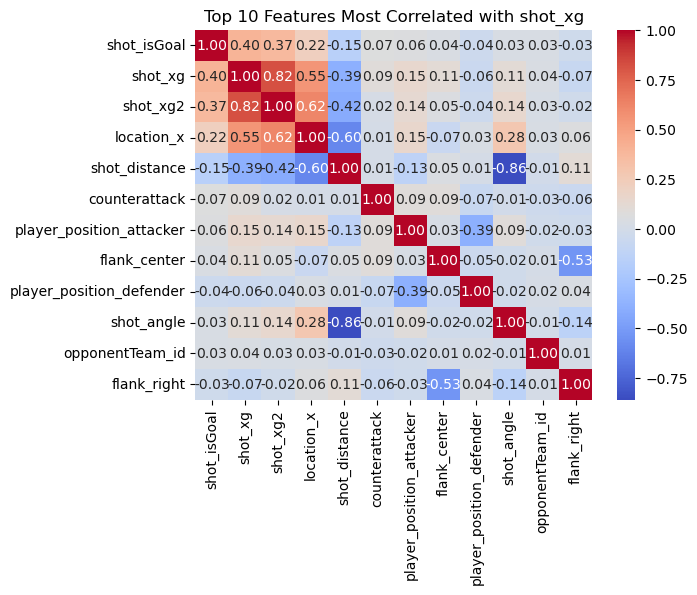

In [921]:
import seaborn as sns
import matplotlib.pyplot as plt

top_corr_goal = corr_goal['shot_isGoal'].abs().sort_values(ascending=False).head(12).index

sns.heatmap(shots[top_corr_goal].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 10 Features Most Correlated with shot_xg")
plt.show()


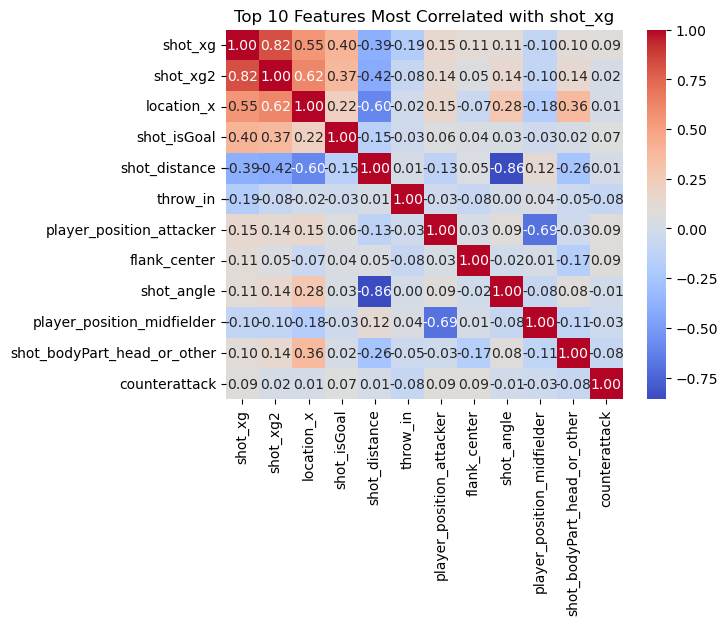

In [922]:
import seaborn as sns
import matplotlib.pyplot as plt

top_corr_xg = corr_xg['shot_xg'].abs().sort_values(ascending=False).head(12).index

sns.heatmap(shots[top_corr_xg].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 10 Features Most Correlated with shot_xg")
plt.show()


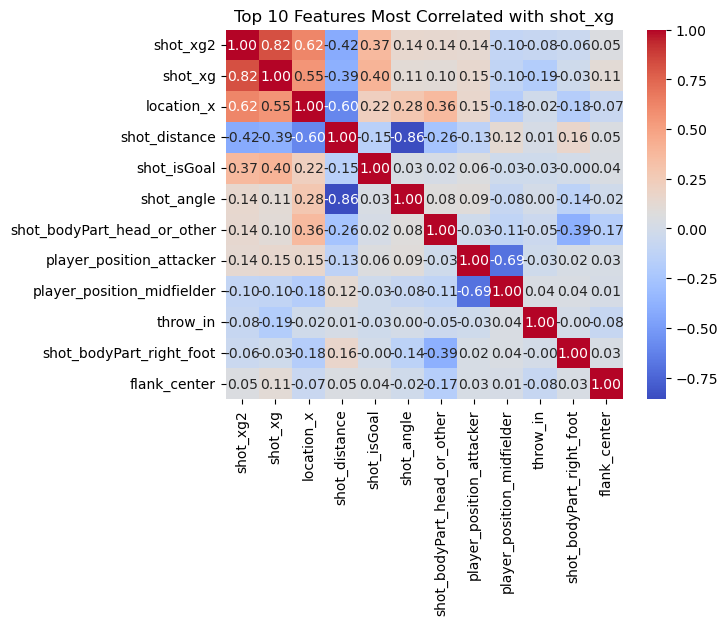

In [923]:
import seaborn as sns
import matplotlib.pyplot as plt

top_corr_xg2 = corr_xg2['shot_xg2'].abs().sort_values(ascending=False).head(12).index

sns.heatmap(shots[top_corr_xg2].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 10 Features Most Correlated with shot_xg")
plt.show()


In [924]:
print("xg corr:", shots["shot_isGoal"].corr(shots["shot_xg"]))
print("xg2 corr:", shots["shot_isGoal"].corr(shots["shot_xg2"]))

xg corr: 0.40187415689393446
xg2 corr: 0.37192182709791877


In [925]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_xg = np.sqrt(mean_squared_error(shots["shot_isGoal"], shots["shot_xg"]))
rmse_xg2 = np.sqrt(mean_squared_error(shots["shot_isGoal"], shots["shot_xg2"]))

print("RMSE xg:", rmse_xg)
print("RMSE xg2:", rmse_xg2)


mae_xg = mean_absolute_error(shots["shot_isGoal"], shots["shot_xg"])
mae_xg2 = mean_absolute_error(shots["shot_isGoal"], shots["shot_xg2"])

print("MAE xg:", mae_xg)
print("MAE xg2:", mae_xg2)

RMSE xg: 0.29791451680977227
RMSE xg2: 0.30250188321666527
MAE xg: 0.17746044901789612
MAE xg2: 0.17335486687036228


In [926]:
games_per_team = shots.groupby('team_name')['matchId'].nunique()


In [927]:
import pandas as pd

# 1. Total goals per team per match
goals_df = shots.groupby(['matchId', 'team_name'])['shot_isGoal'].sum().reset_index()

# 2. Get opponent team names per match
opponents = shots.groupby(['matchId', 'team_name'])['opponentTeam_name'].first().reset_index()
goals_df = goals_df.merge(opponents, on=['matchId', 'team_name'])

# 3. Rename for clarity
team_goals = goals_df.rename(columns={
    'team_name': 'team',
    'opponentTeam_name': 'opponent',
    'shot_isGoal': 'goals'
})

# 4. Merge to get both teams' goals in same row
merged = team_goals.merge(
    team_goals,
    left_on=['matchId', 'opponent'],
    right_on=['matchId', 'team'],
    suffixes=('', '_opponent')
)

# 5. Keep relevant columns
match_outcomes = merged[['matchId', 'team', 'opponent', 'goals', 'goals_opponent']]

# 6. Define result: win / draw / loss
def result(row):
    if row['goals'] > row['goals_opponent']:
        return 'win'
    elif row['goals'] < row['goals_opponent']:
        return 'loss'
    else:
        return 'draw'

match_outcomes['result'] = match_outcomes.apply(result, axis=1)

# 7. Count W/D/L per team
team_results = match_outcomes.groupby('team')['result'].value_counts().unstack(fill_value=0)

# Optional: sort by most wins
team_results = team_results.sort_values('win', ascending=False)

print(team_results)


result                draw  loss  win
team                                 
PSG                      2     4    9
Real Madrid              1     3    8
Arsenal                  4     2    7
Barcelona                1     3    7
Liverpool                1     2    6
Aston Villa              3     1    6
Borussia Dortmund        3     4    6
Feyenoord                2     4    5
Internazionale           4     1    5
Dinamo Zagreb            1     2    4
Lille                    3     2    4
Bayern München           2     4    4
Bayer Leverkusen         1     1    4
Atlético Madrid          0     2    4
Atalanta                 4     2    4
Juventus                 2     3    4
PSV                      4     4    4
Milan                    1     3    3
Manchester United        1     0    3
FCS Bucureşti            0     1    3
Monaco                   0     4    3
Sporting CP              3     3    3
Celtic                   4     3    3
Stuttgart                0     4    3
Benfica     

/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_7907/1874643267.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match_outcomes['result'] = match_outcomes.apply(result, axis=1)


In [928]:
# Group by team
team_stats = shots.groupby('team_name').agg(
    total_shots=('shot_isGoal', 'count'),
    goals=('shot_isGoal', 'sum')
)

# Add accuracy + goal rate
team_stats['goal_rate'] = team_stats['goals'] / team_stats['total_shots']
team_stats = team_stats.sort_values('goal_rate', ascending=False)
team_stats['games_played'] = games_per_team
team_stats = team_stats.merge(team_results, left_index=True, right_index=True, how='left')



In [929]:
print(team_stats)

                      total_shots  goals  goal_rate  games_played  draw  loss  \
team_name                                                                       
Malmö FF                        9      2   0.222222             1     0     0   
Qarabag                         5      1   0.200000             1     0     1   
Dinamo Zagreb                  61     12   0.196721             7     1     2   
Barcelona                     144     28   0.194444            11     1     3   
Crvena Zvezda                  49      9   0.183673             4     1     2   
Lille                          71     13   0.183099             9     3     2   
Arsenal                       142     25   0.176056            13     4     2   
Atlético Madrid                80     14   0.175000             6     0     2   
FCS Bucureşti                  40      7   0.175000             4     0     1   
Bodø / Glimt                   41      7   0.170732             6     2     2   
Real Madrid                 

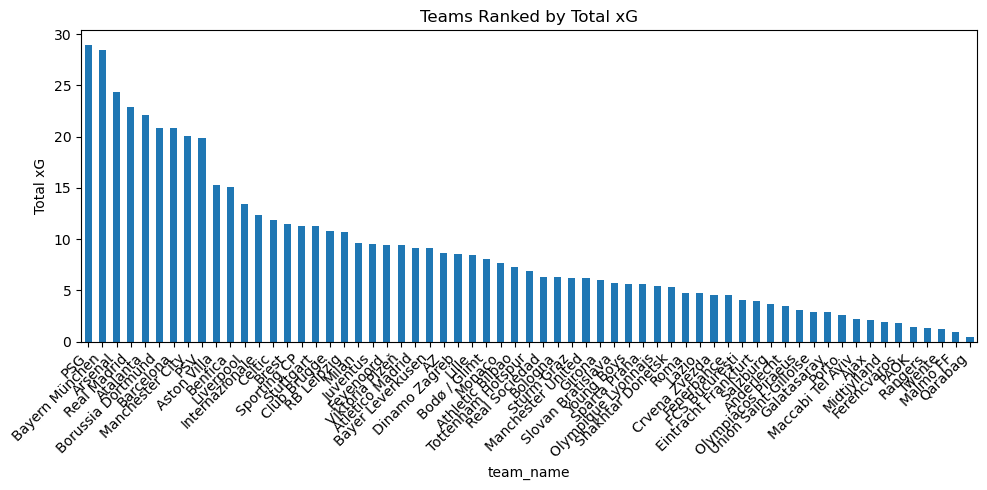

In [930]:
team_totals = (shots.groupby('team_name')['shot_xg']
                      .sum()
                      .sort_values(ascending=False))

plt.figure(figsize=(10, 5))
team_totals.plot(kind='bar')    # bar chart == ranked histogram
plt.ylabel('Total xG')
plt.title('Teams Ranked by Total xG')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [931]:
# print("xg corr:", team_totals["goals"].corr(team_totals["total_xg"]))
# print("xg2 corr:", team_totals["goals"].corr(team_totals["total_xg2"]))
team_totals.head(50)

team_name
PSG                    28.914568
Bayern München         28.437828
Arsenal                24.359140
Real Madrid            22.932526
Atalanta               22.063755
Borussia Dortmund      20.870028
Barcelona              20.820661
Manchester City        20.023405
PSV                    19.896424
Aston Villa            15.307403
Benfica                15.123132
Liverpool              13.431448
Internazionale         12.358655
Celtic                 11.903748
Brest                  11.484974
Sporting CP            11.268473
Stuttgart              11.260389
Club Brugge            10.833136
RB Leipzig             10.709257
Milan                   9.675076
Juventus                9.489662
Feyenoord               9.391189
Viktoria Plzeň          9.391095
Atlético Madrid         9.139291
Bayer Leverkusen        9.093471
AZ                      8.627676
Dinamo Zagreb           8.559850
Lille                   8.432094
Bodø / Glimt            8.094669
Monaco                  7.701566


In [932]:
team_top10 = (shots.groupby('team_name')
                     .agg(total_xg=('shot_xg', 'sum'),
                          total_xg2=('shot_xg2', 'sum'),
                          goals=('shot_isGoal', 'sum'))
                     .sort_values('total_xg', ascending=False)
                     .head(10)
                     .reset_index())

player_top10 = (shots.groupby('player_name')
                      .agg(total_xg=('shot_xg', 'sum'),
                           goals=('shot_isGoal', 'sum'),
                           shots=('id', 'count'))
                      .sort_values('total_xg', ascending=False)
                      .head(10)
                      .reset_index())

In [933]:
print("xg corr:", team_top10["goals"].corr(team_top10["total_xg"]))
print("xg2 corr:", team_top10["goals"].corr(team_top10["total_xg2"]))

xg corr: 0.6041531109961594
xg2 corr: 0.7071916552811857


In [934]:
from sklearn.metrics import mean_absolute_error

mae_xg = mean_absolute_error(team_top10["goals"], team_top10["total_xg"])
mae_xg2 = mean_absolute_error(team_top10["goals"], team_top10["total_xg2"])

print("MAE xg:", mae_xg)
print("MAE xg2:", mae_xg2)


MAE xg: 2.9217085799999998
MAE xg2: 4.467999999999999


In [935]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_xg = np.sqrt(mean_squared_error(team_top10["goals"], team_top10["total_xg"]))
rmse_xg2 = np.sqrt(mean_squared_error(team_top10["goals"], team_top10["total_xg2"]))

print("RMSE xg:", rmse_xg)
print("RMSE xg2:", rmse_xg2)

from sklearn.metrics import mean_absolute_error


RMSE xg: 3.8892302395306095
RMSE xg2: 5.135740316643745


In [936]:
shots['shot_xg2']       = pd.to_numeric(shots.get('shot_xg2'), errors='coerce')
shots['minute_exact']  = shots['minute'] + shots['second'] / 60


team_top10_xg2 = (shots.groupby('team_name')
                     .agg(total_xg2=('shot_xg2', 'sum'),
                          goals=('shot_isGoal', 'sum'))
                     .sort_values('total_xg2', ascending=False)
                     .head(10)
                     .reset_index())

player_top10_xg2 = (shots.groupby('player_name')
                      .agg(total_xg2=('shot_xg', 'sum'),
                           goals=('shot_isGoal', 'sum'),
                           shots=('id', 'count'))
                      .sort_values('total_xg2', ascending=False)
                      .head(10)
                      .reset_index())

In [937]:
print("\nTop-10 teams by total xG")
# print(team_top10.to_string(index=False))
team_top10.head()


Top-10 teams by total xG


,team_name,total_xg,total_xg2,goals
0,PSG,28.914568,27.286,31
1,Bayern München,28.437828,24.088,21
2,Arsenal,24.359140,20.555,25
3,Real Madrid,22.932526,19.551,28
4,Atalanta,22.063755,18.418,21


In [938]:
print("\nTop-10 teams by total xG2")
print(team_top10_xg2.to_string(index=False))


Top-10 teams by total xG2
        team_name  total_xg2  goals
              PSG     27.286     31
   Bayern München     24.088     21
          Arsenal     20.555     25
      Real Madrid     19.551     28
        Barcelona     18.434     28
         Atalanta     18.418     21
Borussia Dortmund     16.888     21
              PSV     16.554     19
  Manchester City     15.924     17
          Benfica     12.478     13


In [939]:
team_summary = (shots.groupby('team_name')
                      .agg(shots=('id', 'count'),
                           goals=('shot_isGoal', 'sum'),
                           total_xg=('shot_xg', 'sum'),
                           avg_xg=('shot_xg', 'mean'),
                           med_xg=('shot_xg', 'median'),
                           total_xg2=('shot_xg2', 'sum'),
                           avg_xg2=('shot_xg2', 'mean'),
                           med_xg2=('shot_xg2', 'median'),
                           conv_rate=('shot_isGoal', 'mean'),
                           avg_dist=('shot_distance', 'mean'))
                      .round(2)
                      .sort_values('total_xg', ascending=False)
                      .head(10))

print("\nDetailed Top-10 team summary")
print(team_summary)


Detailed Top-10 team summary
                   shots  goals  total_xg  avg_xg  med_xg  total_xg2  avg_xg2  \
team_name                                                                       
PSG                  245     31     28.91    0.12    0.07      27.29     0.11   
Bayern München       226     21     28.44    0.13    0.08      24.09     0.11   
Arsenal              142     25     24.36    0.17    0.12      20.56     0.14   
Real Madrid          165     28     22.93    0.14    0.09      19.55     0.12   
Atalanta             156     21     22.06    0.14    0.10      18.42     0.12   
Borussia Dortmund    160     21     20.87    0.13    0.08      16.89     0.11   
Barcelona            144     28     20.82    0.14    0.09      18.43     0.13   
Manchester City      155     17     20.02    0.13    0.09      15.92     0.10   
PSV                  183     19     19.90    0.11    0.07      16.55     0.09   
Aston Villa          107     17     15.31    0.14    0.09      11.80     0.11  

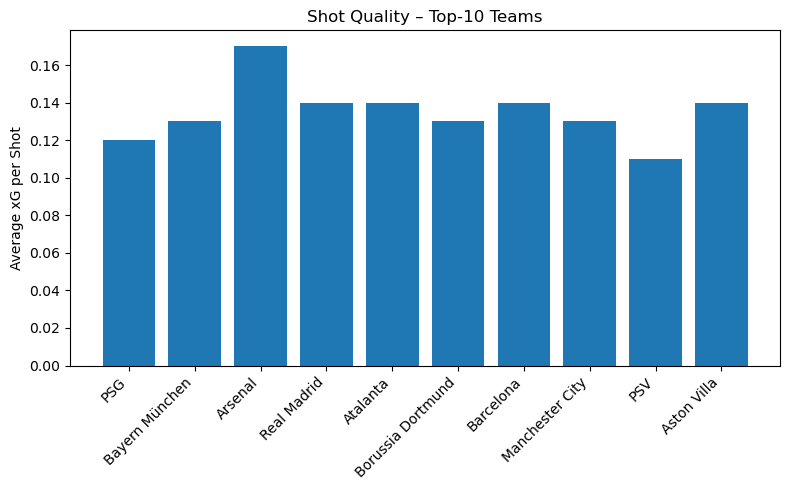

In [940]:
plt.figure(figsize=(8, 5))
plt.bar(team_summary.index, team_summary['avg_xg'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average xG per Shot')
plt.title('Shot Quality – Top-10 Teams')
plt.tight_layout()
plt.show()

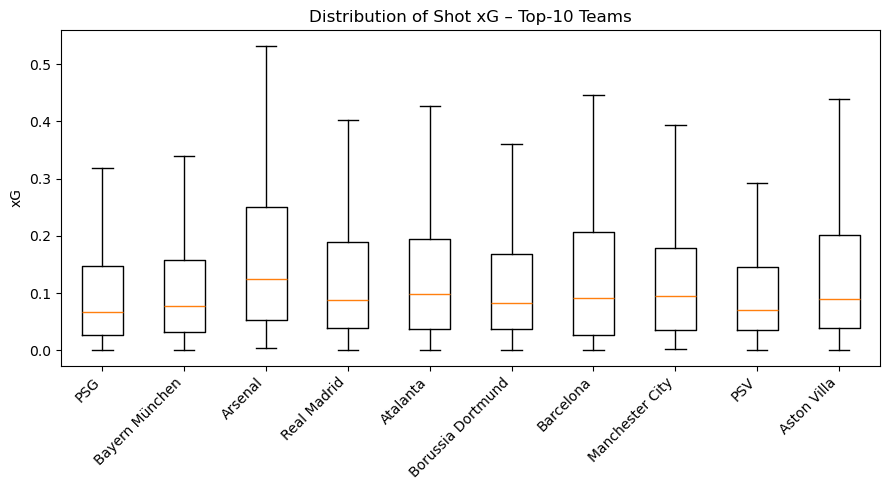

In [941]:
plt.figure(figsize=(9, 5))
box_data = [shots.loc[shots.team_name == t, 'shot_xg'] for t in team_summary.index]
plt.boxplot(box_data, labels=team_summary.index, showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.ylabel('xG')
plt.title('Distribution of Shot xG – Top-10 Teams')
plt.tight_layout()
plt.show()

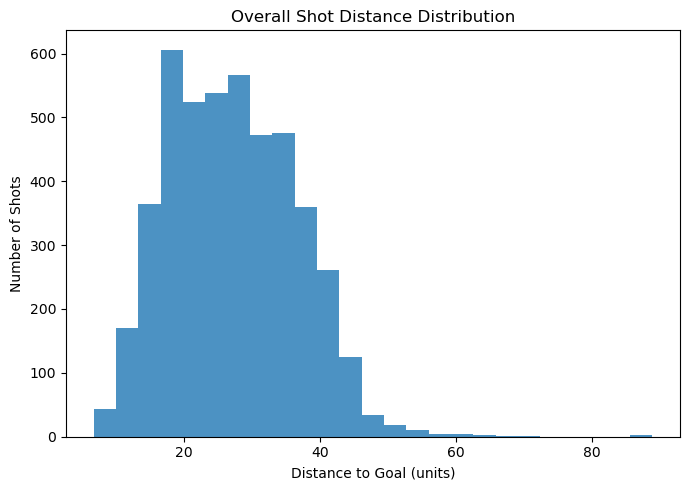

In [942]:
plt.figure(figsize=(7, 5))
plt.hist(shots['shot_distance'], bins=25, alpha=.8)
plt.xlabel('Distance to Goal (units)')
plt.ylabel('Number of Shots')
plt.title('Overall Shot Distance Distribution')
plt.tight_layout()
plt.show()

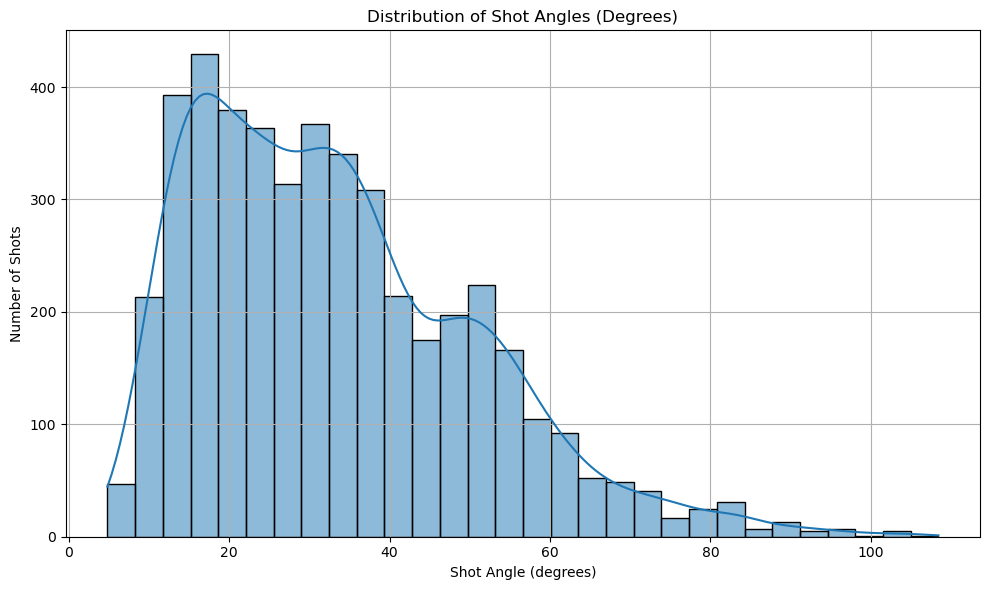

In [943]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(shots['shot_angle'], bins=30, kde=True)
plt.title("Distribution of Shot Angles (Degrees)")
plt.xlabel("Shot Angle (degrees)")
plt.ylabel("Number of Shots")
plt.grid(True)
plt.tight_layout()
plt.show()

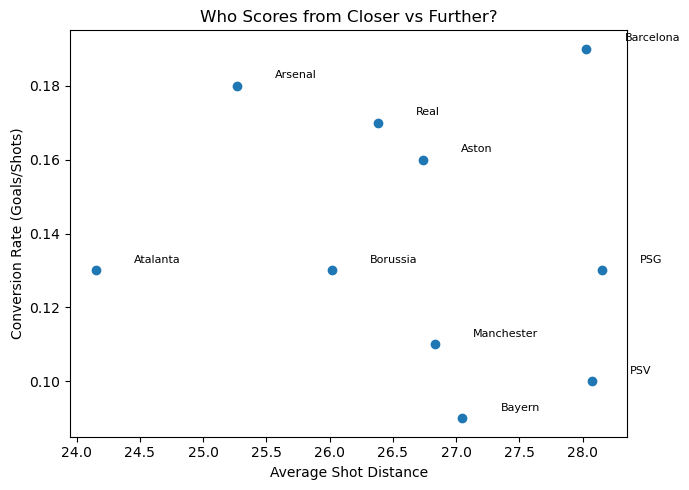

In [944]:
plt.figure(figsize=(7, 5))
plt.scatter(team_summary['avg_dist'], team_summary['conv_rate'])
for team, row in team_summary.iterrows():
    plt.text(row['avg_dist'] + 0.3,
             row['conv_rate'] + 0.002,
             team.split(' ')[0],
             fontsize=8)
plt.xlabel('Average Shot Distance')
plt.ylabel('Conversion Rate (Goals/Shots)')
plt.title('Who Scores from Closer vs Further?')
plt.tight_layout()
plt.show()

In [945]:
print("\nTop-10 players by total xG")
print(player_top10.to_string(index=False))


Top-10 players by total xG
    player_name  total_xg  goals  shots
        H. Kane  7.801916      7     42
      K. Mbappé  6.768256      7     41
    S. Guirassy  6.109559      7     30
     E. Haaland  6.092070      6     30
     B. Barcola  5.561400      3     26
     O. Dembélé  5.320297      8     49
       Raphinha  4.798541     10     35
     L. de Jong  4.419090      2     23
Vinícius Júnior  4.401799      7     31
    V. Pavlidis  4.382569      5     18


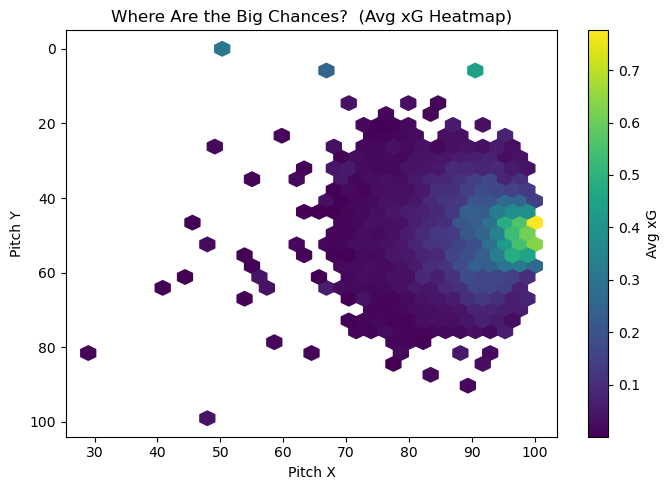

In [946]:
plt.figure(figsize=(7, 5))

valid = shots[['location_x', 'location_y', 'shot_xg']].dropna()

hb = plt.hexbin(valid['location_x'],
                valid['location_y'],
                C=valid['shot_xg'],
                reduce_C_function=np.mean, 
                gridsize=30,
                cmap='viridis')

plt.colorbar(hb, label='Avg xG')
plt.gca().invert_yaxis()
plt.xlabel('Pitch X')
plt.ylabel('Pitch Y')
plt.title('Where Are the Big Chances?  (Avg xG Heatmap)')
plt.tight_layout()
plt.show()


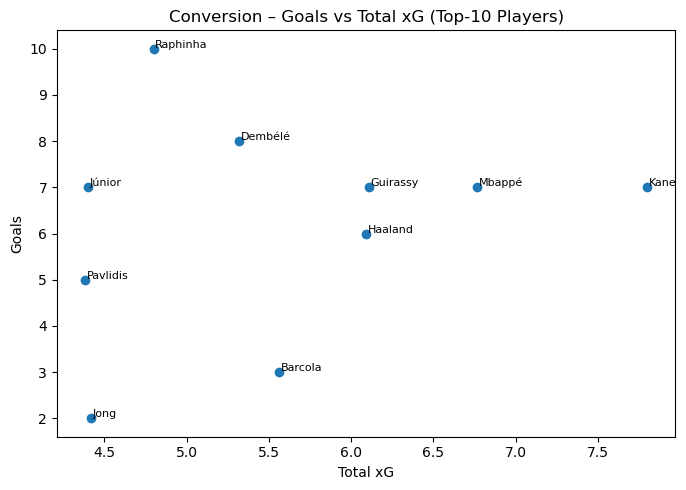

In [947]:
plt.figure(figsize=(7, 5))
plt.scatter(player_top10['total_xg'], player_top10['goals'])
for _, row in player_top10.iterrows():
    last = row['player_name'].split(' ')[-1]
    plt.text(row['total_xg'] + 0.01, row['goals'] + 0.02, last, fontsize=8)
plt.title('Conversion – Goals vs Total xG (Top-10 Players)')
plt.xlabel('Total xG')
plt.ylabel('Goals')
plt.tight_layout()
plt.show()

In [948]:
possible = [c for c in shots.columns
            if c.lower() in ['match_id', 'matchid', 'fixture_id', 'game_id']]
match_col = possible[0]          # pick the first hit



/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_7907/136262247.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))


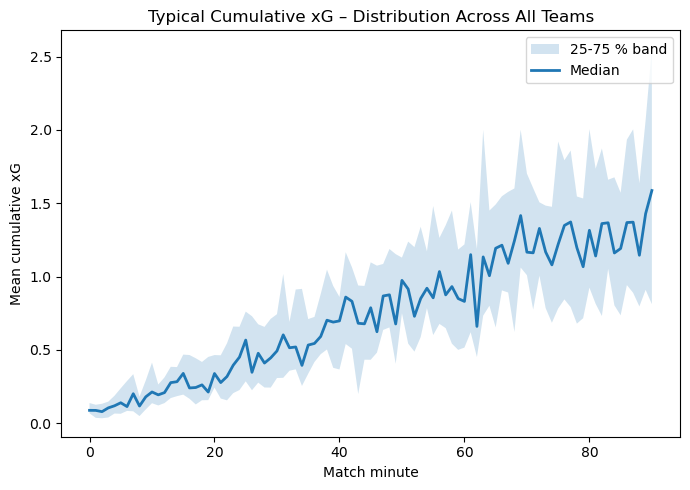

In [949]:
# create integer minute once
shots['minute_int'] = shots['minute_exact'].round().astype(int)

# per-match cumulative xG
match_cum = (shots.sort_values(['team_name', match_col, 'minute_int'])
                   .groupby(['team_name', match_col])
                   .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))
                   .reset_index(drop=True))

# average across matches
mean_curve = (match_cum.groupby(['team_name', 'minute_int'])['cumu']
                       .mean()
                       .reset_index())

pivot = (mean_curve.pivot(index='minute_int',
                          columns='team_name',
                          values='cumu')
                    .reindex(range(0, 91)))      # ensure full minute index

median = pivot.median(axis=1)
p25    = pivot.quantile(0.25, axis=1)
p75    = pivot.quantile(0.75, axis=1)

plt.figure(figsize=(7, 5))
plt.fill_between(pivot.index, p25, p75, alpha=0.2, label='25-75 % band')
plt.plot(pivot.index, median, linewidth=2, label='Median')

plt.xlabel('Match minute')
plt.ylabel('Mean cumulative xG')
plt.title('Typical Cumulative xG – Distribution Across All Teams')
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/9q/c733hdkn4x7643llmv4jdfdw0000gn/T/ipykernel_7907/2218167672.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))


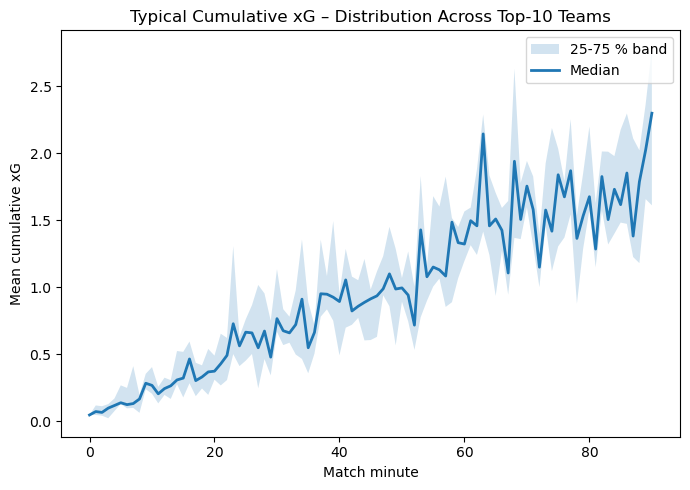

In [950]:
top10_names = team_top10['team_name'].tolist()       
shots_t10   = shots[shots['team_name'].isin(top10_names)].copy()

shots_t10['minute_int'] = shots_t10['minute_exact'].round().astype(int)

match_cum = (shots_t10.sort_values(['team_name', match_col, 'minute_int'])
                    .groupby(['team_name', match_col])
                    .apply(lambda df: df.assign(cumu=df['shot_xg'].cumsum()))
                    .reset_index(drop=True))

mean_curve = (match_cum.groupby(['team_name', 'minute_int'])['cumu']
                       .mean()
                       .reset_index())


pivot  = (mean_curve.pivot(index='minute_int',
                           columns='team_name',
                           values='cumu')
                     .reindex(range(0, 91)))

median = pivot.median(axis=1)
p25    = pivot.quantile(0.25, axis=1)
p75    = pivot.quantile(0.75, axis=1)

plt.figure(figsize=(7, 5))
plt.fill_between(pivot.index, p25, p75, alpha=0.2, label='25-75 % band')
plt.plot(pivot.index, median, linewidth=2, label='Median')

plt.xlabel('Match minute')
plt.ylabel('Mean cumulative xG')
plt.title('Typical Cumulative xG – Distribution Across Top-10 Teams')
plt.legend()
plt.tight_layout()
plt.show()


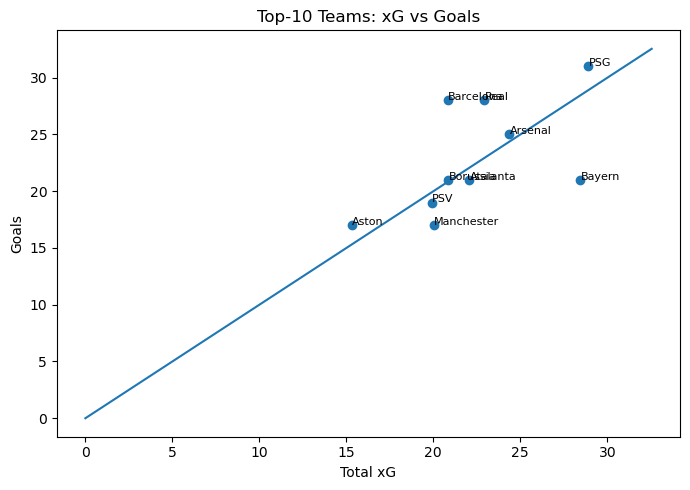

In [951]:
plt.figure(figsize=(7, 5))
plt.scatter(team_top10['total_xg'], team_top10['goals'])
max_val = max(team_top10['total_xg'].max(), team_top10['goals'].max()) * 1.05
plt.plot([0, max_val], [0, max_val])        # 45° reference line
for _, row in team_top10.iterrows():
    plt.text(row['total_xg'] + 0.03,
             row['goals']   + 0.03,
             row['team_name'].split(' ')[0],
             fontsize=8)
plt.xlabel('Total xG')
plt.ylabel('Goals')
plt.title('Top-10 Teams: xG vs Goals')
plt.tight_layout()
plt.show()

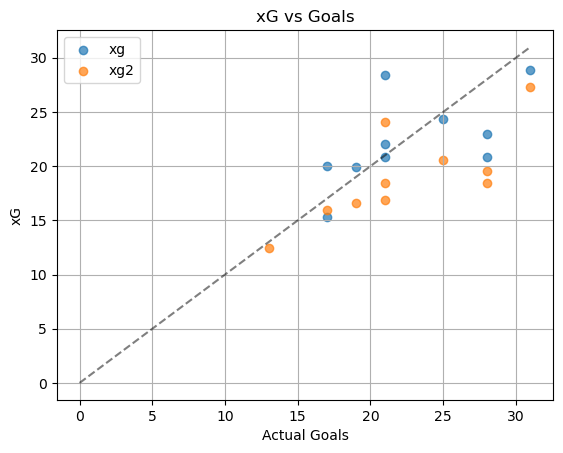

In [952]:
import matplotlib.pyplot as plt

plt.scatter(team_top10["goals"], team_top10["total_xg"], label="xg", alpha=0.7)
plt.scatter(team_top10_xg2["goals"], team_top10_xg2["total_xg2"], label="xg2", alpha=0.7)
plt.plot([0, team_top10["goals"].max()], [0, team_top10["goals"].max()], 'k--', alpha=0.5)
plt.xlabel("Actual Goals")
plt.ylabel("xG")
plt.legend()
plt.title("xG vs Goals")
plt.grid(True)
plt.show()
